In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar
df_sleep = pd.read_csv('04 sleepDay_merged.csv')
print(df_sleep['Id'].nunique())
print()
print(df_sleep['Id'].unique())

24

[1503960366 1644430081 1844505072 1927972279 2026352035 2320127002
 2347167796 3977333714 4020332650 4319703577 4388161847 4445114986
 4558609924 4702921684 5553957443 5577150313 6117666160 6775888955
 6962181067 7007744171 7086361926 8053475328 8378563200 8792009665]


In [3]:

# 2. Tamaño
print("Tamaño del DataFrame:")
print(df_sleep.shape)


# 3. Primeras filas
print()
print("Primeras filas del DataFrame:")
print(df_sleep.head())

# 4. Información general
print(df_sleep.info())

# 5. Estadísticas
print()
print("Descripción estadística del DataFrame:")
print(df_sleep.describe())

# 6. Muestra aleatoria
print()
print("Muestra aleatoria del DataFrame:")
print(df_sleep.sample(10))  

Tamaño del DataFrame:
(413, 5)

Primeras filas del DataFrame:
           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed  
0             346  
1             407  
2             442  
3             367  
4             712  
<class 'pandas.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Id                  413 non-null    int64
 1   SleepDay            413 non-null    str  
 2   TotalSleepRecords   413 non-null    int64
 3   TotalMinut

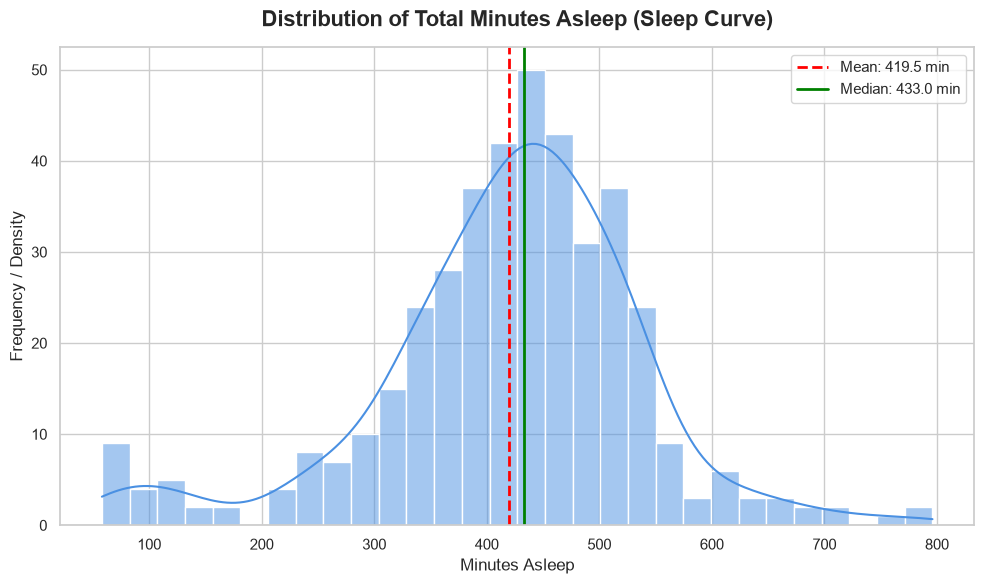

In [ ]:

# Calculate statistics for reference lines
sleep_mean = df_sleep['TotalMinutesAsleep'].mean()
sleep_median = df_sleep['TotalMinutesAsleep'].median()

# Set up the plot size and style
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Create the histogram with a Kernel Density Estimate (KDE) curve (Gauss curve)
sns.histplot(
    data=df_sleep, 
    x='TotalMinutesAsleep', 
    kde=True, 
    color='#4A90E2', 
    bins=30, 
    edgecolor='white'
)

# Add vertical lines representing Mean and Median
plt.axvline(x=sleep_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {sleep_mean:.1f} min')
plt.axvline(x=sleep_median, color='green', linestyle='-', linewidth=2, label=f'Median: {sleep_median:.1f} min')

# Customize executive titles, labels and legend
plt.title('Distribution of Total Minutes Asleep (Sleep Curve)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Minutes Asleep', fontsize=12)
plt.ylabel('Frequency / Density', fontsize=12)
plt.legend(fontsize=11, loc='upper right')

# Display the final plot
plt.tight_layout()
plt.show()

Primeras filas del DataFrame:

           Id   SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366 2016-04-12                  1                 327   
1  1503960366 2016-04-13                  2                 384   
2  1503960366 2016-04-15                  1                 412   
3  1503960366 2016-04-16                  2                 340   
4  1503960366 2016-04-17                  1                 700   

   TotalTimeInBed  DayOfWeek  
0             346    Tuesday  
1             407  Wednesday  
2             442     Friday  
3             367   Saturday  
4             712     Sunday  

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


C:\Users\andre\AppData\Local\Temp\ipykernel_34600\3351674157.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sleep, x='DayOfWeek', order=week_order, palette='viridis')


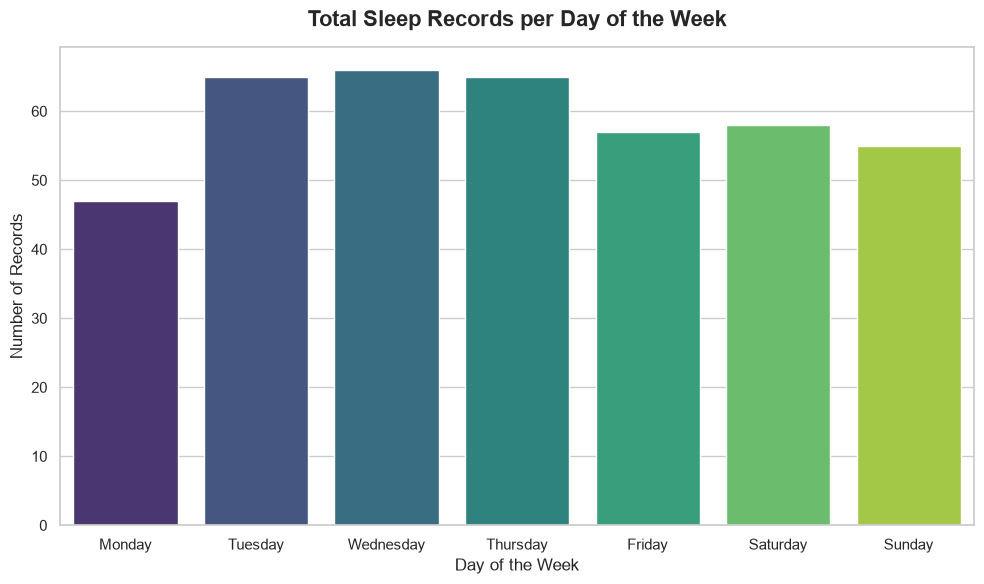

In [18]:
# 1. Convert the SleepDay column to datetime objects
df_sleep['SleepDay'] = pd.to_datetime(df_sleep['SleepDay'])

# 2. Extract the name of the day of the week
df_sleep['DayOfWeek'] = df_sleep['SleepDay'].dt.day_name()

# 3. Set the logical order for the days of the week
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("Primeras filas del DataFrame:")
print()
print(df_sleep.head())

print()
print(week_order)


# 4. Initialize the plot style and size
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# 5. Create the count plot to show records per day
sns.countplot(data=df_sleep, x='DayOfWeek', order=week_order, palette='viridis')

# 6. Add English titles and labels for stakeholders
plt.title('Total Sleep Records per Day of the Week', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

# 7. Final adjustments and display
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# Sleep Summary by User
# ============================================

# Agrupar por usuario
df_sleep_summary = (
    df_sleep
    .groupby("Id")
    .agg(
        Avg_Minutes_Asleep=("TotalMinutesAsleep", "mean"),
        Avg_Time_In_Bed=("TotalTimeInBed", "mean"),
        Avg_Sleep_Records=("TotalSleepRecords", "mean")
    )
    .reset_index()
)

#Paso 2. Convertir minutos a horas
df_sleep_summary["Avg_Sleep_Hours"] = (
    df_sleep_summary["Avg_Minutes_Asleep"] / 60
).round(2)

df_sleep_summary["Avg_Time_In_Bed_Hours"] = (
    df_sleep_summary["Avg_Time_In_Bed"] / 60
).round(2)

# Paso 3. Calcular Sleep Efficiency
df_sleep_summary["Sleep_Efficiency"] = (
    df_sleep_summary["Avg_Minutes_Asleep"]
    /
    df_sleep_summary["Avg_Time_In_Bed"]
    * 100
).round(1)

# Paso 4. Crear categorías
def classify_sleep(x):

    if x >= 95:
        return "Excellent"

    elif x >= 90:
        return "Good"

    elif x >= 85:
        return "Fair"

    else:
        return "Poor"

# Aplicamos la función:    
df_sleep_summary["Sleep_Category"] = (
    df_sleep_summary["Sleep_Efficiency"]
    .apply(classify_sleep)
)

# Paso 5. Ordenar    
df_sleep_summary = (
    df_sleep_summary
    .sort_values(
        by="Sleep_Efficiency",
        ascending=False
    )
)

# Paso 6. Seleccionar columnas
df_sleep_summary = df_sleep_summary[
    [
        "Id",
        "Avg_Sleep_Hours",
        "Avg_Time_In_Bed_Hours",
        "Sleep_Efficiency",
        "Sleep_Category"
    ]
]
print(df_sleep_summary.head(10))

# Paso 8. Exportar
df_sleep_summary.to_csv(
    "04_sleep_summary.csv",
    index=False
)

#print("CSV exported successfully.")

            Id  Avg_Sleep_Hours  Avg_Time_In_Bed_Hours  Sleep_Efficiency  \
21  8053475328             4.95                   5.03              98.5   
20  7086361926             7.55                   7.77              97.2   
18  6962181067             7.47                   7.77              96.1   
23  8792009665             7.26                   7.56              96.0   
19  7007744171             1.14                   1.19              95.8   
13  4702921684             7.02                   7.37              95.3   
3   1927972279             6.95                   7.30              95.2   
9   4319703577             7.94                   8.37              95.0   
17  6775888955             5.83                   6.15              94.8   
10  4388161847             6.72                   7.10              94.6   

   Sleep_Category  
21      Excellent  
20      Excellent  
18      Excellent  
23      Excellent  
19      Excellent  
13      Excellent  
3       Excellent  
9  